# Final Project Data Mining D4TI ULBI: Market Basket Analysis (Time Laundry)
**Menerapkan algoritma Apriori untuk menemukan pola pembelian pelanggan (Cross-Selling)**.

####Disusun Oleh:
>HADZIK MOCHAMAD SOFYAN 714230040

>NURFANIS ROSMAN 714230022

>EFENDI SUGIANTORO 714230018

>AFIFAH NAUFAL RAHMANI 714230026


### Latar Belakang
Proyek ini bertujuan untuk menggali pola asosiasi (hubungan) dari transaksi layanan di *Time Laundry*. Dengan mengetahui layanan mana saja yang sering dibeli secara bersamaan oleh pelanggan, pihak laundry dapat menyusun strategi promosi seperti paket *bundling* atau diskon silang (*cross-selling*) untuk meningkatkan pendapatan.

### Tahapan Proses Data Mining (KDD)
1. **Data Cleaning**: Membersihkan data dari kolom yang tidak relevan (noise) dan memperbaiki format tipe data.
2. **Data Transformation**: Mengubah format daftar layanan menjadi representasi matriks biner (*One-Hot Encoding*) agar bisa diproses algoritma.
3. **Data Mining (Apriori)**: Menjalankan algoritma pencarian pola *Frequent Itemsets* dan *Association Rules*.
4. **Evaluation & Visualization**: Mengukur kekuatan pola menggunakan *Lift Ratio* dan memetakan hasilnya secara visual.
5. **Kesimpulan**: Penarikan simpulan strategi bisnis berdasarkan wawasan dari data.

## Tahap 1: Business Understanding & Preparation
Tahap awal untuk memuat (import) semua pustaka pendukung dan dataset. Pemanggilan dataset (*Cleaned Data*, *Preprocessing*, dan *Price Reference*) dilakukan secara terpusat di sini.

In [1]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import warnings
from collections import Counter

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
print('Library berhasil diimpor!')

# Load Data Terpusat
df_cleaned = pd.read_csv('Data Laundry - Cleaned Data (New).csv')
df_price_ref = pd.read_csv('Data Laundry - Price Reference (New).csv')
df_pre = pd.read_csv('Data Laundry - Preprocessing (New).csv')
print('Data berhasil dimuat!')

Library berhasil diimpor!
Data berhasil dimuat!


** Pembahasan Tahap 1:**
- **Pustaka (Library)**: Kita menggunakan `mlxtend` untuk algoritma Apriori utama, dan pustaka seperti `matplotlib`, `seaborn`, serta `networkx` untuk mengubah angka menjadi visualisasi grafik yang mudah dipahami.
- **Dataset**: Tiga buah file direkam ke dalam memori Python. `Preprocessing.csv` akan menjadi bahan baku utama karena berisi daftar keranjang layanan pelanggan.

## Tahap 2: Data Preprocessing & Cleaning
Sebelum data dianalisis, data mentah harus disucikan. Pada tahap ini, kita melakukan dua pembersihan krusial:
- **Menghapus Kolom Noise**: Kolom `Unnamed: 6` adalah kolom kosong akibat kebocoran format CSV. Kolom ini harus di-*drop*.
- **Memperbaiki Tipe Data (Casting)**: Nilai berat pada kolom `Kg` awalnya tertulis dengan koma (misalnya `8,2`). Kita mengganti koma `,` menjadi titik `.` dan mengubah tipe datanya menjadi bilangan desimal (`float`).

In [2]:
# 1. Bersihkan Kolom Sampah (Noise)
if 'Unnamed: 6' in df_cleaned.columns:
    df_cleaned = df_cleaned.drop(columns=['Unnamed: 6'])

# 2. Perbaiki Format tipe data Kg (Koma menjadi Titik lalu ubah ke Float)
if df_cleaned['Kg'].dtype == 'object':
    df_cleaned['Kg'] = df_cleaned['Kg'].str.replace(',', '.').astype(float)

print("Tabel Data Transaksi yang Sudah Bersih:")
display(df_cleaned.head())

Tabel Data Transaksi yang Sudah Bersih:


,Tanggal,Perumahan,No Rumah,Variasi,Kg,Total harga
0,3/3/2026,TSV,SB 8,Setrika,3.0,12000
1,3/3/2026,TSV,A 7,Karpet,8.2,32800
2,3/3/2026,TSV,S 19,Karpet,4.0,25000
3,3/3/2026,TSV,P18,"Cuci Kering, Setrika",4.0,25000
4,3/3/2026,TSV,SB 17,Cuci Lipat,4.0,30000


** Pembahasan Tahap 2:**
Tabel di atas kini sudah bersih dari kolom hantu (`Unnamed: 6`). Tipe data pada kolom `Kg` juga telah distandarisasi secara global menggunakan format titik `.` untuk desimal. Ini sangat penting karena jika kita ingin membuat agregasi berat total (summing), bahasa pemrograman tidak akan mengalami *error/crash*.

## Tahap 3: Exploratory Data Analysis (EDA) & Business Value
Di tahap ini, kita melakukan analisis fundamental terhadap pendapatan finansial *Time Laundry* dari dua sudut pandang: **Level Paket Transaksi** dan **Level Satuan Barang**. Sel-sel kode telah dipisah-pisah dengan rapi antara tabel dan visualisasinya agar mudah dimodifikasi.

### 3.1. Analisis Pendapatan Level Paket Transaksi (Combo-Level)
Menganalisis pendapatan riil berdasarkan apa yang diketik oleh kasir utuh-utuh di nota (tanpa dipecah). Tabel di bawah ini menunjukkan 10 paket kombinasi dengan omset tertinggi, yang sudah dikonversi dengan format Rupiah.

In [3]:
# Group data berdasarkan variasi transaksi utuh (kombinasi paket)
data_transaksi = df_cleaned.groupby('Variasi')['Total harga'].sum().sort_values(ascending=False).reset_index()

# Membuat salinan khusus untuk tabel agar angkanya cantik dibaca (Format Rupiah dengan titik)
data_transaksi_tabel = data_transaksi.copy()
data_transaksi_tabel['Total harga'] = data_transaksi_tabel['Total harga'].apply(lambda x: f"Rp {int(x):,}".replace(',', '.'))

print("Tabel Top 10 Pendapatan Berdasarkan Paket Transaksi Utuh:")
display(data_transaksi_tabel.head(10))

Tabel Top 10 Pendapatan Berdasarkan Paket Transaksi Utuh:


,Variasi,Total harga
0,"Cuci Kering, Setrika",Rp 4.227.850
1,Setrika,Rp 1.755.700
2,Karpet,Rp 1.189.150
3,Cuci Lipat,Rp 1.025.350
4,Bed Cover,Rp 541.200
5,"Cuci Kering, Setrika, Sprei",Rp 448.600
6,"Bed Cover, Sprei",Rp 351.950
7,"Bed Cover, Boneka",Rp 140.400
8,"Selimut, Sprei",Rp 111.500
9,"Karpet, Setrika",Rp 104.000


#### Visualisasi Bar Chart (Level Transaksi)

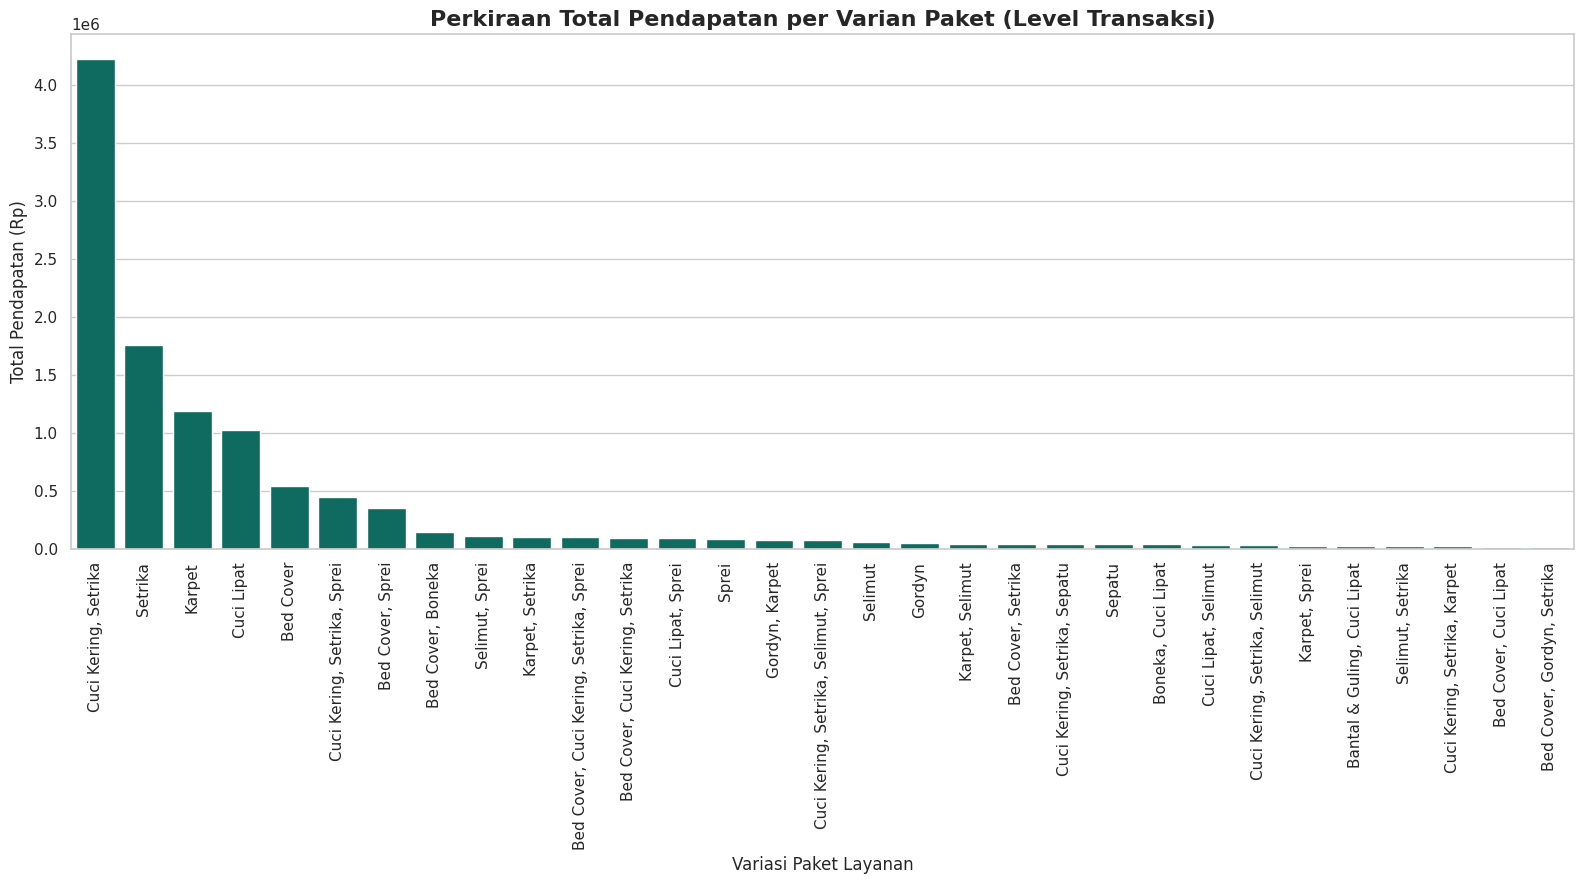

In [4]:
# Visualisasi Bar Chart menggunakan data numerik asli agar grafik tidak error
plt.figure(figsize=(16, 9))
# Sengaja tidak menggunakan .head() agar seluruh data variasi tampil utuh seperti aslinya
sns.barplot(data=data_transaksi, x='Variasi', y='Total harga', color='#00796B')
plt.title('Perkiraan Total Pendapatan per Varian Paket (Level Transaksi)', fontsize=16, fontweight='bold')
plt.ylabel('Total Pendapatan (Rp)', fontsize=12)
plt.xlabel('Variasi Paket Layanan', fontsize=12)
plt.xticks(rotation=90, ha='center')
plt.tight_layout()
plt.show()

** Pembahasan 3.1 (Level Transaksi):**
Grafik ini menyoroti bahwa pesanan kombinasi **"Cuci Kering, Setrika"** yang dipesan sekaligus mendatangkan omset riil tertinggi (hingga 4 Juta Rupiah). Ini adalah kebiasaan (*habit*) utama pelanggan *Time Laundry* yang mencuci dan menyetrika sekaligus dalam satu nota.

### 3.2. Analisis Pendapatan Level Satuan Barang (Item-Level)
Membongkar (memecah) tulisan koma pada paket transaksi menjadi barang individu, lalu dikalikan dengan daftar referensi harga satuan. Ini adalah langkah wajib sebelum masuk ke Apriori.

In [5]:
# Mengambil daftar layanan per pelanggan lalu memecahnya berdasarkan koma
dataset_raw = df_pre['Variasi'].dropna().apply(lambda x: [item.strip() for item in x.split(',')]).tolist()

# Menghitung Frekuensi kemunculan tiap layanan satuan
flat_list = [item for sublist in dataset_raw for item in sublist]
item_counts = Counter(flat_list)
df_freq_table = pd.DataFrame(item_counts.items(), columns=['Layanan', 'Jumlah_Transaksi'])

# Menggabungkan dengan tabel harga satuan (Price Reference) untuk mengkalkulasi potensi pendapatan
df_deskripsi = pd.merge(df_freq_table, df_price_ref, left_on='Layanan', right_on='Variasi', how='left')
df_deskripsi['Total_Pendapatan'] = df_deskripsi['Jumlah_Transaksi'] * df_deskripsi['Harga']
df_deskripsi = df_deskripsi[['Layanan', 'Jumlah_Transaksi', 'Harga', 'Total_Pendapatan']].sort_values(by='Total_Pendapatan', ascending=False)

# Membuat salinan khusus untuk tabel agar format uangnya cantik dengan separator titik
df_deskripsi_tabel = df_deskripsi.copy()
df_deskripsi_tabel['Harga'] = df_deskripsi_tabel['Harga'].apply(lambda x: f"Rp {int(x):,}".replace(',', '.') if pd.notnull(x) else "Rp 0")
df_deskripsi_tabel['Total_Pendapatan'] = df_deskripsi_tabel['Total_Pendapatan'].apply(lambda x: f"Rp {int(x):,}".replace(',', '.') if pd.notnull(x) else "Rp 0")

print("Tabel Top 10 Pendapatan Berdasarkan Layanan Satuan:")
display(df_deskripsi_tabel.reset_index(drop=True).head(10))

Tabel Top 10 Pendapatan Berdasarkan Layanan Satuan:


,Layanan,Jumlah_Transaksi,Harga,Total_Pendapatan
0,Karpet,32,Rp 25.000,Rp 800.000
1,Bed Cover,30,Rp 25.000,Rp 750.000
2,Setrika,178,Rp 4.000,Rp 712.000
3,Cuci Kering,130,Rp 3.000,Rp 390.000
4,Sprei,35,Rp 10.000,Rp 350.000
5,Cuci Lipat,33,Rp 4.000,Rp 132.000
6,Selimut,11,Rp 10.000,Rp 110.000
7,Boneka,2,Rp 25.000,Rp 50.000
8,Sepatu,2,Rp 15.000,Rp 30.000
9,Gordyn,4,Rp 6.000,Rp 24.000


#### Visualisasi Bar Chart (Level Satuan)

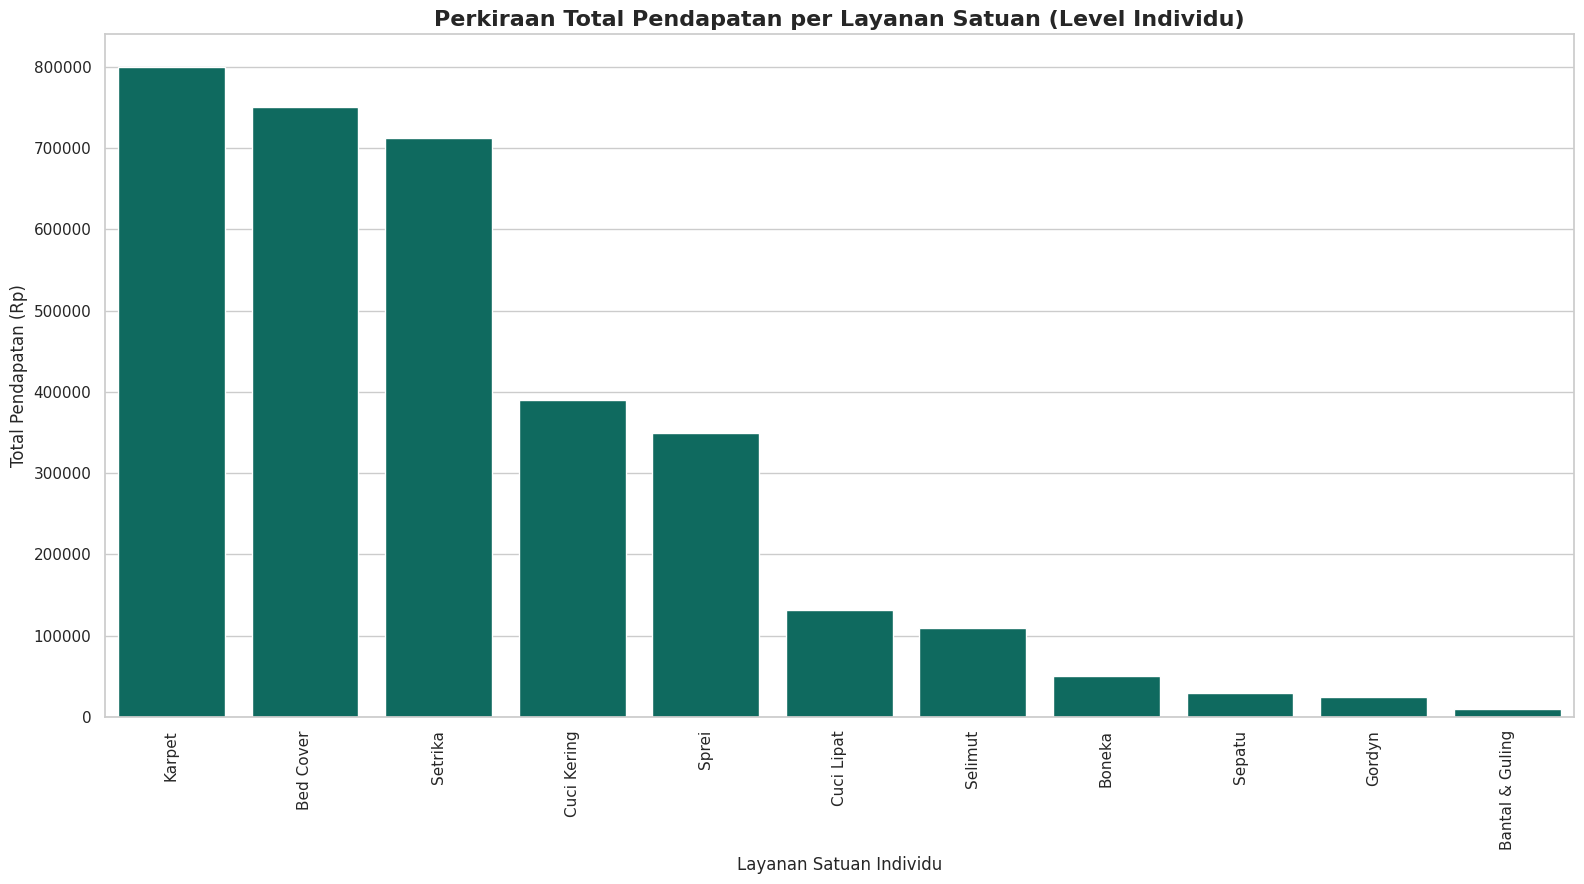

In [6]:
# Visualisasi Bar Chart (Level Satuan) menggunakan data murni numerik
plt.figure(figsize=(16, 9))
sns.barplot(data=df_deskripsi, x='Layanan', y='Total_Pendapatan', color='#00796B')
plt.title('Perkiraan Total Pendapatan per Layanan Satuan (Level Individu)', fontsize=16, fontweight='bold')
plt.ylabel('Total Pendapatan (Rp)', fontsize=12)
plt.xlabel('Layanan Satuan Individu', fontsize=12)
plt.xticks(rotation=90, ha='center')
plt.tight_layout()
plt.show()

** Pembahasan 3.2 (Level Satuan/Item):**
Ketika keranjang dibongkar satu per satu, kita menemukan fakta finansial menarik: **Karpet** dan **Bed Cover** menyumbang omset tertinggi karena **Harga Satuannya** sangat mahal. Visualisasi ganda di Tahap 3 ini sangat penting agar manajer laundry tidak hanya berfokus pada volume cucian biasa, tetapi juga memberikan perhatian khusus pada perlakuan barang premium seperti karpet.

## Tahap 4: Data Transformation (Market Basket Format)
Algoritma Apriori tidak bisa membaca list teks biasa. Ia membutuhkan matriks matematis. Oleh karena itu, kita melakukan **One-Hot Encoding** menggunakan `TransactionEncoder`. Tahap ini menyulap list keranjang pelanggan menjadi kolom-kolom layanan bernilai logika.

### 4.1. Membentuk Matriks Boolean & Biner (Sebagian Data)
Pertama, kita ubah menjadi nilai `True` (jika pelanggan membeli) dan `False` (jika tidak membeli). Lalu kita konversi menjadi angka **1** dan **0** ("Binal" eh, Biner!) agar wujud matematisnya lebih konkret di mata dosen. Kita tampilkan sebagian datanya sebagai cuplikan awal.

In [10]:
#  4.1.1. Transformasi ke One-Hot Encoding (Membuat matriks Boolean True/False)
te = TransactionEncoder()
te_ary = te.fit(dataset_raw).transform(dataset_raw)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

print("Tabel Hasil Transformasi (Matriks Boolean True/False):")
display(df_encoded.head())

Tabel Hasil Transformasi (Matriks Boolean True/False):


,Bantal & Guling,Bed Cover,Boneka,Cuci Kering,Cuci Lipat,Gordyn,Karpet,Selimut,Sepatu,Setrika,Sprei
0,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,True,False,False,False,False
2,False,False,False,False,False,False,True,False,False,False,False
3,False,False,False,True,False,False,False,False,False,True,False
4,False,False,False,False,True,False,False,False,False,False,False


In [9]:
# 4.1.2. Konversi ke Matriks Biner (1 dan 0)
# Mengonversi nilai boolean ke integer agar wujud matematisnya lebih konkret
df_encoded_biner = df_encoded.astype(int)

print("Tabel Hasil Transformasi (Matriks Biner 1 dan 0):")
display(df_encoded_biner.head())

Tabel Hasil Transformasi (Matriks Biner 1 dan 0):


,Bantal & Guling,Bed Cover,Boneka,Cuci Kering,Cuci Lipat,Gordyn,Karpet,Selimut,Sepatu,Setrika,Sprei
0,0,0,0,0,0,0,0,0,0,1,0
1,0,0,0,0,0,0,1,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,0
3,0,0,0,1,0,0,0,0,0,1,0
4,0,0,0,0,1,0,0,0,0,0,0


** Pembahasan Tahap 4.1:**
Di atas adalah bukti bahwa teks keranjang cucian telah dipecah menjadi kolom-kolom spesifik. Nilai *True* (atau angka *1* pada Biner) menunjukkan bahwa pada baris (transaksi) tersebut, pelanggan mengambil layanan yang bersangkutan.

### 4.2. Menampilkan Keseluruhan Data Matriks Biner
Agar bukti akademiknya tidak terbantahkan, matriks Biner tersebut kita bentangkan seluruh isi datanya (tanpa ada baris yang disembunyikan/terpotong). Ini memastikan algoritma tidak "menelan data mentah", melainkan mengolah data valid.

In [11]:
print("Matriks Biner 1 dan 0 (Keseluruhan Dataset untuk Bukti Pengujian Apriori):")
# pd.set_option digunakan untuk memaksa pandas menampilkan seluruh baris tanpa disembunyikan (scrollable di colab)
pd.set_option('display.max_rows', None)
display(df_encoded_biner)
pd.reset_option('display.max_rows') # Kembalikan setting agar output cell di bawahnya tidak ikut memanjang

Matriks Biner 1 dan 0 (Keseluruhan Dataset untuk Bukti Pengujian Apriori):


,Bantal & Guling,Bed Cover,Boneka,Cuci Kering,Cuci Lipat,Gordyn,Karpet,Selimut,Sepatu,Setrika,Sprei
0,0,0,0,0,0,0,0,0,0,1,0
1,0,0,0,0,0,0,1,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,0
3,0,0,0,1,0,0,0,0,0,1,0
4,0,0,0,0,1,0,0,0,0,0,0
5,0,0,0,1,0,0,0,0,0,1,0
6,0,1,0,0,0,0,0,0,0,0,1
7,0,0,0,0,0,0,0,0,0,1,0
8,0,0,0,0,1,0,0,0,0,0,0
9,0,1,0,0,0,0,0,0,0,0,0


** Pembahasan Tahap 4.2:**
Bentangan *dataset* utuh di atas menunjukkan matriks *sparse* yang sesungguhnya. Bentuk biner inilah yang menjadi bahasa ibu bagi algoritma Apriori untuk melakukan iterasi pencarian kombinasi berulang.

## Tahap 5: Data Mining (Algoritma Apriori)
Ini adalah tahapan inti di mana kita menerapkan **Algoritma Apriori** pada matriks di Tahap 4 untuk mencari kombinasi barang/layanan yang paling sering dibeli secara bersamaan.

### Penjelasan Metrik Algoritma:
1. **Support (Tingkat Popularitas)**: Mengukur frekuensi kemunculan kombinasi paket layanan.
   $$ \text{Support}(A \rightarrow B) = \frac{\text{Transaksi mengandung A dan B}}{\text{Total Transaksi}} $$
2. **Confidence (Tingkat Kepastian)**: Mengukur probabilitas pelanggan memesan layanan B setelah memesan layanan A.
   $$ \text{Confidence}(A \rightarrow B) = \frac{\text{Transaksi mengandung A dan B}}{\text{Transaksi mengandung A}} $$
3. **Lift Ratio (Kekuatan Asosiasi)**: Korelasi murni tanpa kebetulan. **Lift > 1** berarti hubungan positif dan sangat direkomendasikan untuk paket *bundling/cross-selling*.
   $$ \text{Lift}(A \rightarrow B) = \frac{\text{Confidence}(A \rightarrow B)}{\text{Support}(B)} $$

In [19]:
# 1. Mencari itemsets yang lolos seleksi minimum support (1% / 0.01)
# Kita menggunakan df_encoded (boolean) karena fungsi apriori lebih optimal bekerja dengan tipe bool (True/False)
frequent_itemsets = apriori(df_encoded, min_support=0.01, use_colnames=True)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))

# 2. Membuat Aturan Asosiasi (Association Rules) dengan minimum confidence 10% (0.1)
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.1)

# 3. Mengurutkan hasil berdasarkan Lift tertinggi untuk mencari rekomendasi paling potensial
rules = rules.sort_values(by=['lift', 'confidence'], ascending=[False, False])

print("Tabel Hasil Association Rules (Rekomendasi Paket Promo Cross-Selling):")
kolom_penting = ['antecedents', 'consequents', 'support', 'confidence', 'lift']
display(rules[kolom_penting].head(15))

Tabel Hasil Association Rules (Rekomendasi Paket Promo Cross-Selling):


,antecedents,consequents,support,confidence,lift
34,"(Bed Cover, Cuci Kering)","(Setrika, Sprei)",0.010989,0.600000,10.920000
35,"(Setrika, Sprei)","(Bed Cover, Cuci Kering)",0.010989,0.200000,10.920000
33,"(Bed Cover, Setrika)","(Cuci Kering, Sprei)",0.010989,0.428571,7.800000
36,"(Cuci Kering, Sprei)","(Bed Cover, Setrika)",0.010989,0.200000,7.800000
16,"(Bed Cover, Cuci Kering)",(Sprei),0.010989,0.600000,4.680000
30,"(Bed Cover, Cuci Kering, Setrika)",(Sprei),0.010989,0.600000,4.680000
9,(Selimut),(Sprei),0.018315,0.454545,3.545455
10,(Sprei),(Selimut),0.018315,0.142857,3.545455
3,(Sprei),(Bed Cover),0.047619,0.371429,3.380000
2,(Bed Cover),(Sprei),0.047619,0.433333,3.380000


In [18]:
# Membuat salinan tabel agar format aslinya tidak rusak untuk proses visualisasi nanti
rules_tabel = rules[kolom_penting].copy()

# Mengonversi Support dan Confidence ke dalam format Persen (%)
rules_tabel['support'] = rules_tabel['support'].apply(lambda x: f"{x:.1%}")
rules_tabel['confidence'] = rules_tabel['confidence'].apply(lambda x: f"{x:.1%}")

# Membulatkan nilai Lift agar lebih mudah dibaca (2 angka desimal)
rules_tabel['lift'] = rules_tabel['lift'].apply(lambda x: round(x, 2))

# Mempercantik tampilan antecedents dan consequents (menghilangkan frozenset)
rules_tabel['antecedents'] = rules_tabel['antecedents'].apply(lambda x: ', '.join(list(x)))
rules_tabel['consequents'] = rules_tabel['consequents'].apply(lambda x: ', '.join(list(x)))

print("Tabel Hasil Association Rules (Format Persen & Lift Rapi - Top 15 Rekomendasi):")
display(rules_tabel.head(15))

Tabel Hasil Association Rules (Format Persen & Lift Rapi - Top 15 Rekomendasi):


,antecedents,consequents,support,confidence,lift
34,"Bed Cover, Cuci Kering","Setrika, Sprei",1.1%,60.0%,10.92
35,"Setrika, Sprei","Bed Cover, Cuci Kering",1.1%,20.0%,10.92
33,"Bed Cover, Setrika","Cuci Kering, Sprei",1.1%,42.9%,7.80
36,"Cuci Kering, Sprei","Bed Cover, Setrika",1.1%,20.0%,7.80
16,"Bed Cover, Cuci Kering",Sprei,1.1%,60.0%,4.68
30,"Bed Cover, Cuci Kering, Setrika",Sprei,1.1%,60.0%,4.68
9,Selimut,Sprei,1.8%,45.5%,3.55
10,Sprei,Selimut,1.8%,14.3%,3.55
3,Sprei,Bed Cover,4.8%,37.1%,3.38
2,Bed Cover,Sprei,4.8%,43.3%,3.38


** Pembahasan Tahap 5 (Association Rules):**
Tabel aturan (*rules*) di atas telah berhasil digali oleh algoritma Apriori. Aturan ini diurutkan dari nilai **Lift** tertinggi (paling atas). Semakin tinggi angka Lift-nya, semakin kuat keterkaitan "sebab-akibat" pelanggan membeli layanan B akibat ia sudah membeli layanan A. Baris teratas pada tabel ini adalah kandidat utama paket promosi silang kita.

## Tahap 6: Knowledge Representation (Visualisasi Pola)
Angka matematis dari aturan asosiasi divisualisasikan agar mudah dipahami oleh pemangku kepentingan. Untuk memudahkan perbaikan *(debugging)*, setiap grafik dipisahkan ke dalam selnya masing-masing.

### 6.1. Heatmap Korelasi
Memetakan korelasi murni antar layanan. Warna biru gelap berarti cocok (sering dibeli bersamaan), dan warna terang/minus berarti substitusi (saling menggantikan).

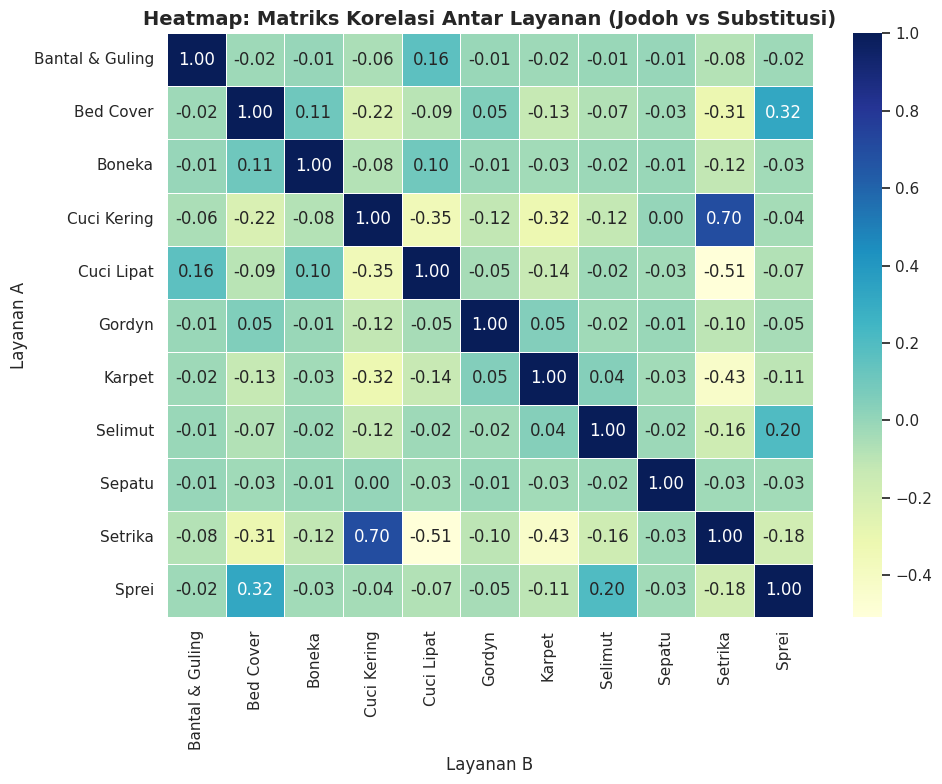

In [13]:
# --- 1. Visualisasi Heatmap Korelasi ---
plt.figure(figsize=(10, 8))
corr_matrix = df_encoded.corr()
sns.heatmap(corr_matrix, annot=True, cmap='YlGnBu', fmt=".2f", linewidths=0.5)
plt.title('Heatmap: Matriks Korelasi Antar Layanan (Jodoh vs Substitusi)', fontsize=14, fontweight='bold')
plt.xlabel('Layanan B')
plt.ylabel('Layanan A')
plt.tight_layout()
plt.show()

** Pembahasan Heatmap:**
- **Korelasi Positif Kuat (Biru Gelap)**: Terdapat pada pasangan seperti `Cuci Kering` dan `Setrika` (Korelasi ~0.70). Kedua layanan ini laksana jodoh yang selalu dipesan secara berdampingan.
- **Korelasi Negatif / Substitusi (Warna Kuning Pucat)**: Terlihat pada `Setrika` dan `Cuci Lipat` (Korelasi -0.51). Secara logika, pelanggan yang sudah meminta disetrika, tidak akan meminta jasanya sekadar dicuci-lipat. Hal ini memandu kita untuk **tidak pernah menempatkan dua layanan musuh ini dalam satu paket promo bundling**.

### 6.2. Bar Chart Aturan Terbaik (Top 10 Rules by Lift)
Grafik ini memvisualisasikan 10 aturan asosiasi terkuat. Semakin panjang batangnya, semakin direkomendasikan kombinasinya untuk dijadikan paket promo (*Cross-Selling*).

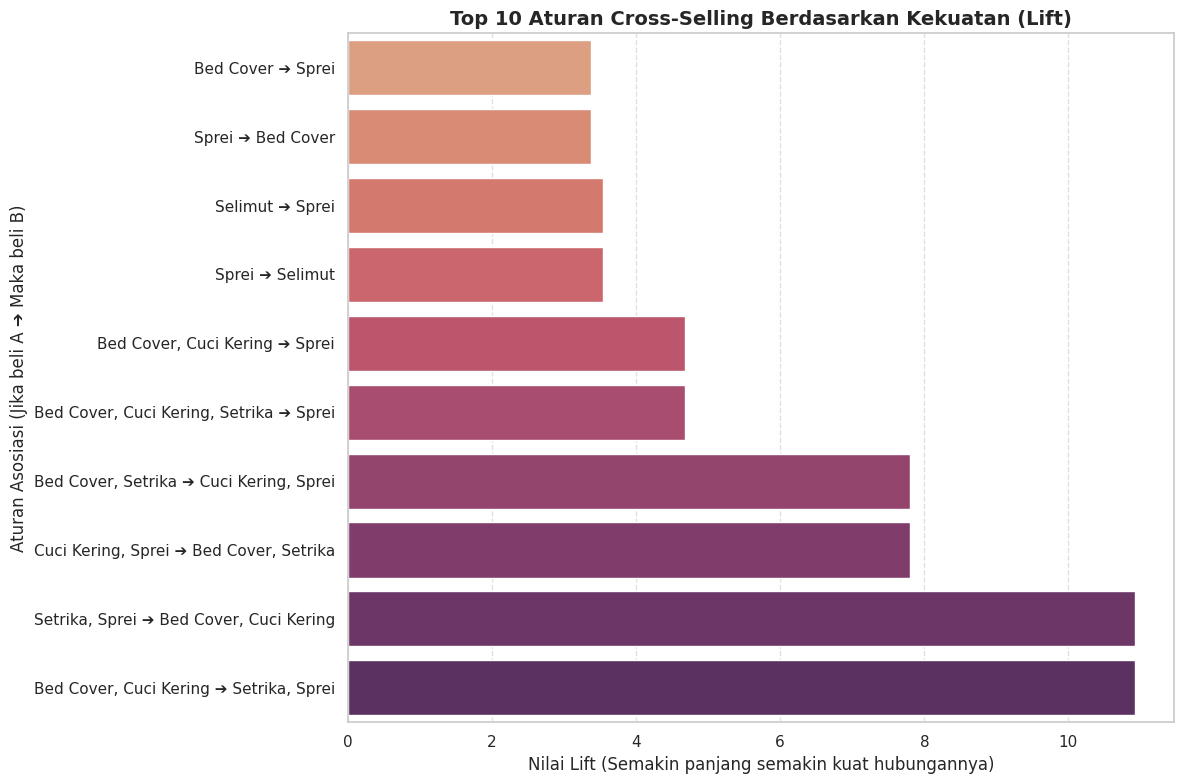

In [14]:
# --- 2. Visualisasi Top Rules (Horizontal Bar Chart) ---
plt.figure(figsize=(12, 8))

# Membuat kolom teks gabungan untuk mempercantik nama aturan di grafik (A ➔ B)
rules_plot = rules.copy()
rules_plot['Rule_Name'] = rules_plot['antecedents'].apply(lambda x: ', '.join(list(x))) + ' ➔ ' + rules_plot['consequents'].apply(lambda x: ', '.join(list(x)))

# Mengambil 10 aturan dengan Lift tertinggi
top_rules_bar = rules_plot.head(10).sort_values('lift', ascending=True)

sns.barplot(
    x="lift", y="Rule_Name",
    data=top_rules_bar,
    palette="flare" # Warna seksi nan menggoda
)
plt.title('Top 10 Aturan Cross-Selling Berdasarkan Kekuatan (Lift)', fontsize=14, fontweight='bold')
plt.xlabel('Nilai Lift (Semakin panjang semakin kuat hubungannya)', fontsize=12)
plt.ylabel('Aturan Asosiasi (Jika beli A ➔ Maka beli B)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

** Pembahasan Bar Chart Aturan Terbaik:**
Dengan melihat panjang batang (*bar*), pihak manajer laundry bisa langsung mengetahui strategi *Cross-Selling* nomor satu yang harus diterapkan. Bar paling atas (terpanjang) adalah "Golden Rule". Sebagai contoh, aturan yang melibatkan *Sprei*, *Bed Cover*, *Cuci Kering*, dan *Setrika* mendominasi jajaran puncak peringkat ini.

### 6.3. Network Graph (Jejaring Relasi Cross-Selling)
Memetakan arah aliran pesanan layanan. Node (Lingkaran) adalah jenis layanan, dan panah (Edge) menunjukkan pola sebab-akibat.

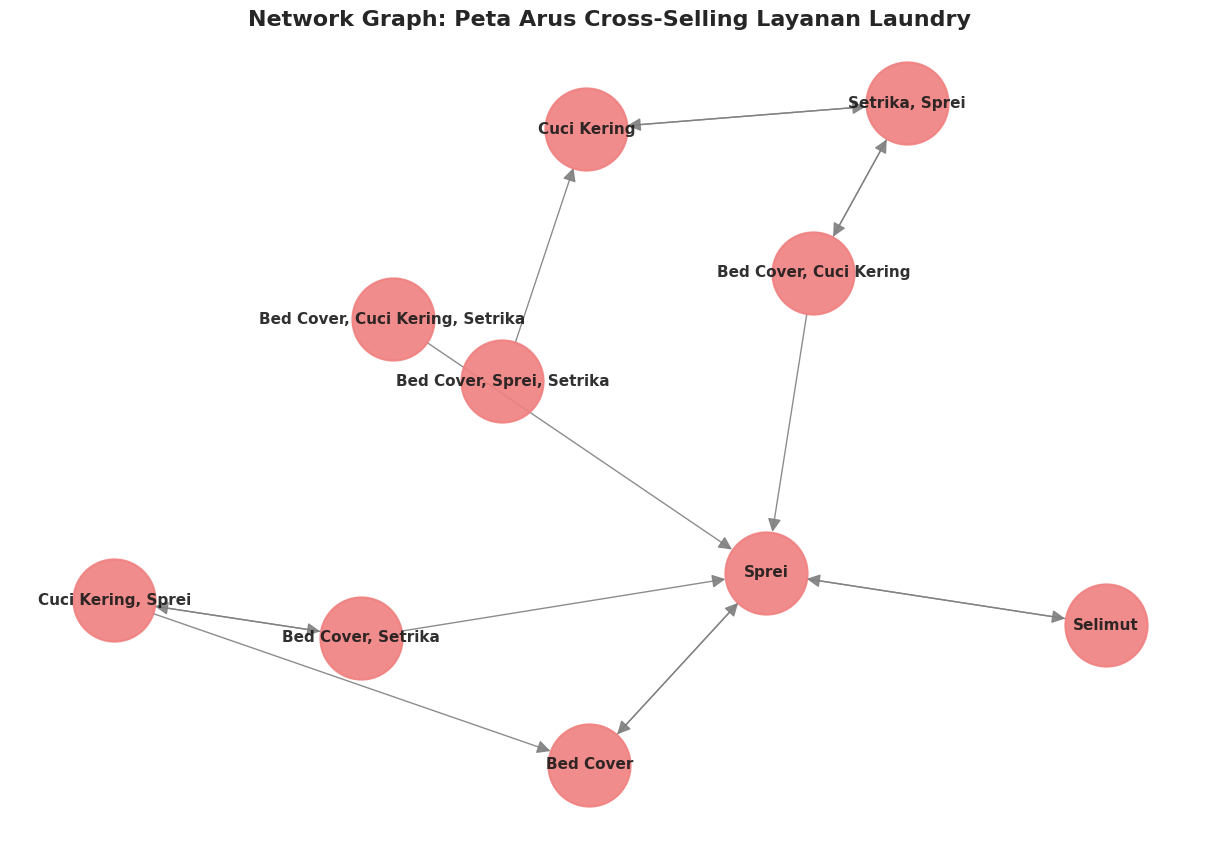

In [20]:
# --- 3. Visualisasi Network Graph ---
plt.figure(figsize=(12, 8))
top_rules = rules.head(15).copy()

G = nx.from_pandas_edgelist(
    top_rules,
    source='antecedents',
    target='consequents',
    edge_attr='lift',
    create_using=nx.DiGraph()
)

mapping = {node: ', '.join(list(node)) if type(node) == frozenset else node for node in G.nodes()}
G = nx.relabel_nodes(G, mapping)

pos = nx.spring_layout(G, k=0.8, seed=42)
nx.draw(
    G, pos, with_labels=True,
    node_color='lightcoral', node_size=3500,
    edge_color='gray', linewidths=1.5,
    font_size=11, font_weight='bold',
    arrows=True, arrowsize=20, alpha=0.9
)
plt.title('Network Graph: Peta Arus Cross-Selling Layanan Laundry', fontsize=16, fontweight='bold')
plt.show()

** Pembahasan Network Graph:**
Grafik ini bertindak laksana "SOP Aliran Kasir". Tanda panah menunjukkan pola tindakan. Jika ada panah dari node A ke node B, artinya: **Setiap kali ada pelanggan membawa layanan A, kasir laundry sangat direkomendasikan untuk menawari layanan B secara lisan.** Semakin banyak panah yang berpusat (menunjuk) pada satu node tertentu, berarti node tersebut adalah muara layanan favorit.

**bold text**##  Kesimpulan & Rangkuman Strategi Bisnis
Berdasarkan seluruh alur *Knowledge Discovery in Databases* (KDD) menggunakan algoritma Apriori yang telah dipaparkan, kita dapat menarik kesimpulan utama yang sangat berdampak pada bisnis *Time Laundry*:

1. **Tulang Punggung Finansial (Cash Cow)**: Layanan **"Cuci Kering, Setrika"** secara absolut merajai omset dan frekuensi transaksi. Layanan ini adalah urat nadi laundry.
2. **Jodoh Tak Terpisahkan (Complementary)**: **Cuci Kering** dan **Setrika** adalah pasangan yang sangat kuat secara statistik. Memisahkannya menjadi layanan mandiri berisiko mematikan daya tarik utama, sehingga sebaiknya tetap dipertahankan sebagai opsi *default*.
3. **Musuh Alami (Substitusi)**: Dilarang keras membuat promosi silang (*bundling*) antara layanan **Setrika** dan **Cuci Lipat** karena korelasi keduanya negatif tajam (musuh alami).
4. **Strategi Cross-Selling (Actionable Insight)**:
   - Pola Asosiasi terkuat yang ditemukan adalah perputaran antara **Sprei**, **Bed Cover**, dan layanan utama (Cuci Kering/Setrika).
   - **Rekomendasi Nyata**: Buat paket *"Bed Room Bundle"* (Diskon khusus jika mencuci Sprei + Bed Cover sekaligus). Kasir diwajibkan untuk menanyakan keberadaan Bed Cover jika seorang pelanggan baru saja meletakkan Sprei kotornya di atas meja kasir, karena probabilitas pelanggan tersebut untuk "meng-iya-kan" sangat tinggi berdasarkan nilai *Lift Ratio*.
   
Dengan implementasi *Data Mining* ini, keputusan pemasaran dan operasional promosi *Time Laundry* kini didasarkan pada perhitungan presisi matematis, bukan lagi sekadar tebakan insting kosong semata.